# Lab 06 — Anomaly Detection using VAE and GAN
## CS23B1028 R K Larika & CS23B1050 S Harshini

## 0 · Setup & Imports

In [2]:
import os
for item in os.listdir('/kaggle/input'):
    print(item)

datasets


In [3]:
import os
for item in os.listdir('/kaggle/input/datasets'):
    print(item)

mateuszbuda


In [4]:
import os
for item in os.listdir('/kaggle/input/datasets/mateuszbuda'):
    print(item)

lgg-mri-segmentation


In [5]:
import os
print(os.listdir('/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m')[:5])

['TCGA_DU_7010_19860307', 'TCGA_DU_8162_19961029', 'TCGA_FG_A4MT_20020212', 'TCGA_FG_5964_20010511', 'TCGA_DU_A5TS_19970726']


In [6]:
import os
os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.environ["TORCHDYNAMO_DISABLE"] = "1"

import os, glob, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

Using device: cuda


## 1 · Data Loading & Preprocessing

In [7]:
DATA_ROOT  = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m'
OUT_DIR    = '/kaggle/working'   # all saved files go here
IMG_SIZE  = 128
BATCH_SIZE = 32

# ── Collect all MRI images and masks ─────────────────────────────────────────
all_images = sorted(glob.glob(os.path.join(DATA_ROOT, '**', '*.tif'), recursive=True))
# Masks contain '_mask' in their filename
mask_files = [f for f in all_images if '_mask' in f]
img_files  = [f for f in all_images if '_mask' not in f]
mask_dict  = {f.replace('_mask', ''): f for f in mask_files}

print(f'Total MRI slices : {len(img_files)}')
print(f'Total mask files : {len(mask_files)}')

# ── Label: abnormal if its mask has ANY white pixels ─────────────────────────
def has_tumour(mask_path):
    m = np.array(Image.open(mask_path).convert('L'))
    return m.max() > 0

labels = []
valid_imgs = []
for fp in img_files:
    mask_fp = mask_dict.get(fp)
    if mask_fp:
        labels.append(1 if has_tumour(mask_fp) else 0)
        valid_imgs.append(fp)

labels     = np.array(labels)
normal_imgs = [fp for fp, l in zip(valid_imgs, labels) if l == 0]
abnormal_imgs = [fp for fp, l in zip(valid_imgs, labels) if l == 1]
print(f'Normal slices  : {len(normal_imgs)}')
print(f'Abnormal slices: {len(abnormal_imgs)}')

Total MRI slices : 3929
Total mask files : 3929
Normal slices  : 2556
Abnormal slices: 1373


In [8]:
# ── Transforms ───────────────────────────────────────────────────────────────
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize([0.5], [0.5])          # → [-1, 1]
])
eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])

class MRIDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = paths
        self.tf    = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')  # grayscale
        if self.tf:
            img = self.tf(img)
        return img

# Train/val on normal; test on abnormal
norm_train, norm_val = train_test_split(normal_imgs, test_size=0.15, random_state=SEED)

train_ds  = MRIDataset(norm_train,   train_tf)
val_ds    = MRIDataset(norm_val,     eval_tf)
abn_ds    = MRIDataset(abnormal_imgs, eval_tf)
# For ROI analysis on normal (false-positive check)
norm_test_ds = MRIDataset(random.sample(normal_imgs, min(200, len(normal_imgs))), eval_tf)

train_loader   = DataLoader(train_ds,     batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader     = DataLoader(val_ds,       batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
abn_loader     = DataLoader(abn_ds,       batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
norm_t_loader  = DataLoader(norm_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Abnormal batches: {len(abn_loader)}')

Train batches: 68 | Val batches: 12 | Abnormal batches: 43


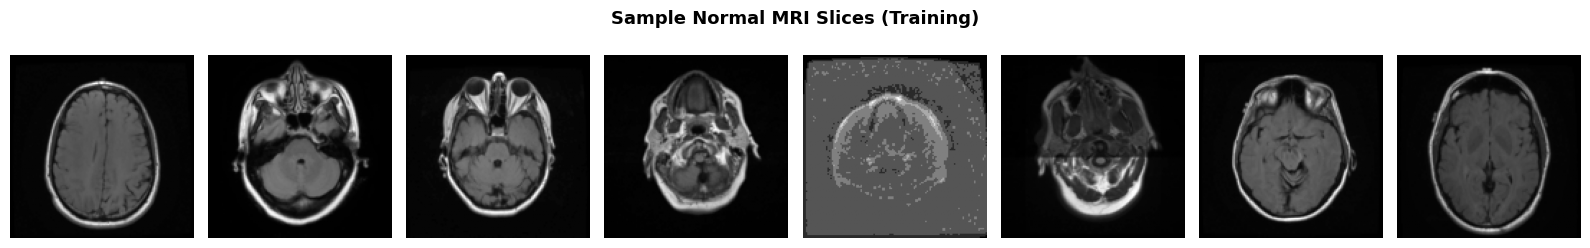

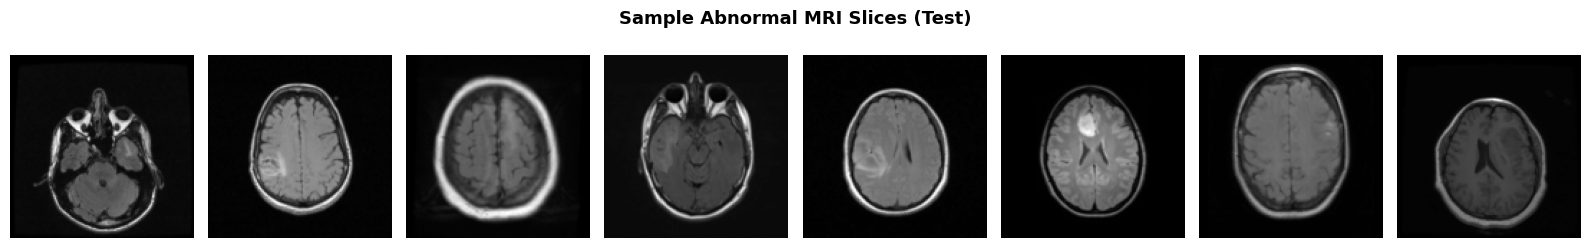

In [9]:
# ── Visualise sample images ───────────────────────────────────────────────────
def unnorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

def show_samples(ds, title, n=8):
    idxs = random.sample(range(len(ds)), n)
    imgs = torch.stack([ds[i] for i in idxs])
    imgs = unnorm(imgs)
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, img in zip(axes, imgs):
        ax.imshow(img.squeeze(), cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_ds,  'Sample Normal MRI Slices (Training)')
show_samples(abn_ds,    'Sample Abnormal MRI Slices (Test)')

## 2 · Variational Autoencoder (VAE)

In [10]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.LeakyReLU(0.2),   # 64
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),  # 32
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2), # 16
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2), # 8
            nn.Flatten()
        )
        self.fc_mu  = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_log = nn.Linear(256 * 8 * 8, latent_dim)

    def forward(self, x):
        h  = self.enc(x)
        mu = self.fc_mu(h)
        lv = self.fc_log(h)
        return mu, lv


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.proj = nn.Linear(latent_dim, 256 * 8 * 8)
        self.dec  = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(), # 16
            nn.ConvTranspose2d(128, 64,  4, 2, 1), nn.BatchNorm2d(64),  nn.ReLU(), # 32
            nn.ConvTranspose2d(64,  32,  4, 2, 1), nn.BatchNorm2d(32),  nn.ReLU(), # 64
            nn.ConvTranspose2d(32,  1,   4, 2, 1), nn.Tanh()                        # 128
        )

    def forward(self, z):
        h = self.proj(z).view(-1, 256, 8, 8)
        return self.dec(h)


class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)
        self.latent_dim = latent_dim

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z   = self.reparameterise(mu, log_var)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var


def vae_loss(x, x_hat, mu, log_var, beta=1.0):
    """ELBO = Reconstruction loss (MSE) + β · KL divergence"""
    recon = F.mse_loss(x_hat, x, reduction='sum') / x.size(0)
    kl    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    return recon + beta * kl, recon, kl


LATENT_DIM = 128
vae = VAE(LATENT_DIM).to(DEVICE)
print(f'VAE parameters: {sum(p.numel() for p in vae.parameters()):,}')

VAE parameters: 7,687,425


In [11]:
VAE_EPOCHS = 50
BETA       = 1.0    # KL weight; try 4.0 for β-VAE
LR_VAE     = 1e-4

vae_opt = torch.optim.Adam(vae.parameters(), lr=LR_VAE)
vae_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(vae_opt, patience=5, factor=0.5)

vae_train_losses = []
vae_recon_losses = []
vae_kl_losses    = []
vae_val_losses   = []

best_val_loss = float('inf')

for epoch in range(1, VAE_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    vae.train()
    t_total = t_recon = t_kl = 0.0
    for batch in train_loader:
        x = batch.to(DEVICE)
        vae_opt.zero_grad()
        x_hat, mu, lv = vae(x)
        loss, recon, kl = vae_loss(x, x_hat, mu, lv, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        vae_opt.step()
        t_total += loss.item(); t_recon += recon.item(); t_kl += kl.item()

    n = len(train_loader)
    vae_train_losses.append(t_total / n)
    vae_recon_losses.append(t_recon / n)
    vae_kl_losses.append(t_kl / n)

    # ── Val ────────────────────────────────────────────────────────────────
    vae.eval()
    v_total = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(DEVICE)
            x_hat, mu, lv = vae(x)
            loss, _, _ = vae_loss(x, x_hat, mu, lv, BETA)
            v_total += loss.item()
    val_l = v_total / len(val_loader)
    vae_val_losses.append(val_l)
    vae_scheduler.step(val_l)

    if val_l < best_val_loss:
        best_val_loss = val_l
        torch.save(vae.state_dict(), f'{OUT_DIR}/vae_best.pth')

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{VAE_EPOCHS}  '
              f'Train {t_total/n:.2f}  (Recon {t_recon/n:.2f} | KL {t_kl/n:.2f})  '
              f'Val {val_l:.2f}')

vae.load_state_dict(torch.load(f'{OUT_DIR}/vae_best.pth'))
print('\nBest VAE loaded.')

Epoch  10/50  Train 317.76  (Recon 261.92 | KL 55.84)  Val 316.90
Epoch  20/50  Train 252.63  (Recon 196.35 | KL 56.28)  Val 266.93
Epoch  30/50  Train 225.31  (Recon 170.44 | KL 54.86)  Val 235.74
Epoch  40/50  Train 207.16  (Recon 153.86 | KL 53.30)  Val 215.98
Epoch  50/50  Train 196.78  (Recon 144.44 | KL 52.34)  Val 203.46

Best VAE loaded.


## 3 · GAN (Encoder-Decoder Generator)

In [12]:
# ── Generator: U-Net style encoder-decoder that reconstructs input ────────────
class GANGenerator(nn.Module):
    """Autoencoder generator: reconstructs normal anatomy; fails on tumours."""
    def __init__(self):
        super().__init__()
        # Encoder
        self.e1 = nn.Sequential(nn.Conv2d(1, 64, 4, 2, 1), nn.LeakyReLU(0.2))  # 64
        self.e2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2))  # 32
        self.e3 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2)) # 16
        self.e4 = nn.Sequential(nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2)) # 8
        # Bottleneck
        self.bn = nn.Sequential(nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU())                               # 4
        # Decoder with skip connections
        self.d1 = nn.Sequential(nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), nn.Dropout(0.5))  # 8
        self.d2 = nn.Sequential(nn.ConvTranspose2d(1024, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU()) # 16
        self.d3 = nn.Sequential(nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU())  # 32
        self.d4 = nn.Sequential(nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU())    # 64
        self.out = nn.Sequential(nn.ConvTranspose2d(128, 1, 4, 2, 1), nn.Tanh())                         # 128

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        b  = self.bn(e4)
        d1 = self.d1(b)
        d2 = self.d2(torch.cat([d1, e4], 1))
        d3 = self.d3(torch.cat([d2, e3], 1))
        d4 = self.d4(torch.cat([d3, e2], 1))
        return self.out(torch.cat([d4, e1], 1))


# ── Discriminator: PatchGAN ───────────────────────────────────────────────────
class GANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 1, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1, 4, 1, 1)   # PatchGAN output
        )

    def forward(self, x):
        return self.net(x)


G = GANGenerator().to(DEVICE)
D = GANDiscriminator().to(DEVICE)
print(f'Generator params    : {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')

Generator params    : 16,655,361
Discriminator params: 2,764,481


In [13]:
GAN_EPOCHS = 50
LR_G = 2e-4; LR_D = 1e-4
LAMBDA_RECON = 100.0   # weight for reconstruction loss vs adversarial

g_opt = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))

adv_loss = nn.BCEWithLogitsLoss()
rec_loss = nn.L1Loss()

gan_g_losses = []; gan_d_losses = []
gan_adv_losses = []; gan_rec_losses = []

def make_labels(patch_out, real=True):
    lbl = torch.ones_like(patch_out) if real else torch.zeros_like(patch_out)
    return lbl * 0.9 if real else lbl + 0.1   # label smoothing


for epoch in range(1, GAN_EPOCHS + 1):
    G.train(); D.train()
    ep_g = ep_d = ep_adv = ep_rec = 0.0

    for real in train_loader:
        real = real.to(DEVICE)

        # ── Discriminator step ───────────────────────────────────────────
        with torch.no_grad():
            fake = G(real)
        d_real = D(real)
        d_fake = D(fake.detach())
        loss_d = 0.5 * (adv_loss(d_real, make_labels(d_real, True)) +
                         adv_loss(d_fake, make_labels(d_fake, False)))
        d_opt.zero_grad(); loss_d.backward(); d_opt.step()

        # ── Generator step ───────────────────────────────────────────────
        fake = G(real)
        d_fake2 = D(fake)
        loss_adv = adv_loss(d_fake2, make_labels(d_fake2, True))
        loss_rec = rec_loss(fake, real) * LAMBDA_RECON
        loss_g   = loss_adv + loss_rec
        g_opt.zero_grad(); loss_g.backward(); g_opt.step()

        ep_g += loss_g.item(); ep_d += loss_d.item()
        ep_adv += loss_adv.item(); ep_rec += loss_rec.item()

    n = len(train_loader)
    gan_g_losses.append(ep_g / n); gan_d_losses.append(ep_d / n)
    gan_adv_losses.append(ep_adv / n); gan_rec_losses.append(ep_rec / n)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{GAN_EPOCHS}  G {ep_g/n:.3f}  '
              f'(Adv {ep_adv/n:.3f} | Rec {ep_rec/n:.3f})  D {ep_d/n:.3f}')

torch.save(G.state_dict(), f'{OUT_DIR}/gan_G_best.pth')
print('GAN training done.')

Epoch  10/50  G 2.984  (Adv 1.395 | Rec 1.589)  D 0.601
Epoch  20/50  G 3.183  (Adv 1.894 | Rec 1.289)  D 0.458
Epoch  30/50  G 3.184  (Adv 2.001 | Rec 1.183)  D 0.392
Epoch  40/50  G 3.083  (Adv 2.002 | Rec 1.082)  D 0.387
Epoch  50/50  G 1.535  (Adv 0.695 | Rec 0.840)  D 0.693
GAN training done.


## 4 · Training Loss Curves

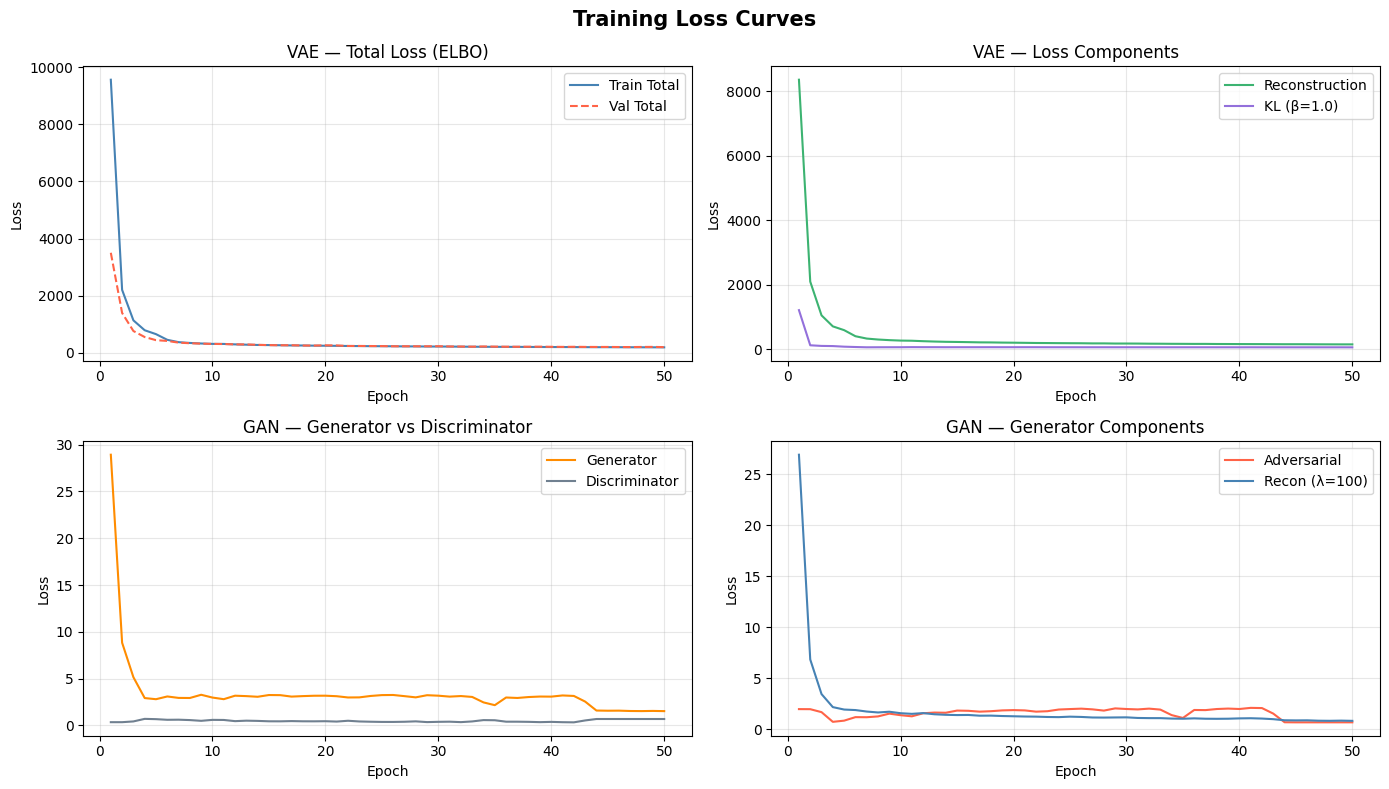

In [14]:
epochs_vae = range(1, VAE_EPOCHS + 1)
epochs_gan = range(1, GAN_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Training Loss Curves', fontsize=15, fontweight='bold')

# VAE total loss
ax = axes[0, 0]
ax.plot(epochs_vae, vae_train_losses, label='Train Total', color='steelblue')
ax.plot(epochs_vae, vae_val_losses,   label='Val Total',   color='tomato', linestyle='--')
ax.set_title('VAE — Total Loss (ELBO)'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# VAE components
ax = axes[0, 1]
ax.plot(epochs_vae, vae_recon_losses, label='Reconstruction', color='mediumseagreen')
ax.plot(epochs_vae, vae_kl_losses,    label=f'KL (β={BETA})',  color='mediumpurple')
ax.set_title('VAE — Loss Components'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# GAN total losses
ax = axes[1, 0]
ax.plot(epochs_gan, gan_g_losses, label='Generator',     color='darkorange')
ax.plot(epochs_gan, gan_d_losses, label='Discriminator', color='slategray')
ax.set_title('GAN — Generator vs Discriminator'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# GAN generator breakdown
ax = axes[1, 1]
ax.plot(epochs_gan, gan_adv_losses, label='Adversarial',    color='tomato')
ax.plot(epochs_gan, gan_rec_losses, label=f'Recon (λ={LAMBDA_RECON:.0f})', color='steelblue')
ax.set_title('GAN — Generator Components'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Latent Space Visualisation (VAE)

Running t-SNE on 840 samples (200 normal, 640 abnormal)...


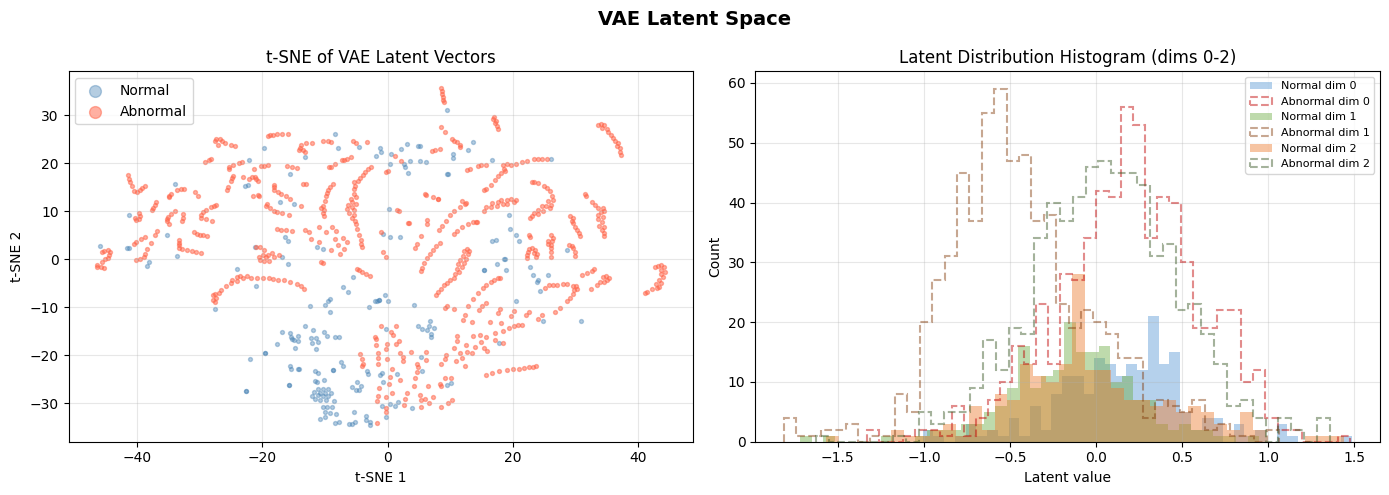

In [15]:
def extract_latents(model, loader, max_batches=20):
    model.eval()
    mus = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            x = batch.to(DEVICE)
            mu, _ = model.encoder(x)
            mus.append(mu.cpu().numpy())
    return np.concatenate(mus)

mu_normal   = extract_latents(vae, norm_t_loader)
mu_abnormal = extract_latents(vae, abn_loader)

n_normal = len(mu_normal)
n_abn    = len(mu_abnormal)
all_mu   = np.concatenate([mu_normal, mu_abnormal])

print(f'Running t-SNE on {len(all_mu)} samples ({n_normal} normal, {n_abn} abnormal)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
emb  = tsne.fit_transform(all_mu)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VAE Latent Space', fontsize=14, fontweight='bold')

# t-SNE scatter
ax = axes[0]
ax.scatter(emb[:n_normal, 0],   emb[:n_normal, 1],   s=8,  alpha=0.4, label='Normal',   color='steelblue')
ax.scatter(emb[n_normal:, 0],   emb[n_normal:, 1],   s=8,  alpha=0.5, label='Abnormal', color='tomato')
ax.set_title('t-SNE of VAE Latent Vectors')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(markerscale=3); ax.grid(alpha=0.3)

# Latent distribution histogram (first 3 dims)
ax = axes[1]
for dim, col_n, col_a in zip(range(3),
                              ['#5b9bd5', '#70ad47', '#ed7d31'],
                              ['#c00000', '#843c0c', '#375623']):
    ax.hist(mu_normal[:, dim],   bins=40, alpha=0.45, color=col_n, label=f'Normal dim {dim}')
    ax.hist(mu_abnormal[:, dim], bins=40, alpha=0.45, color=col_a, linestyle='--', histtype='step', linewidth=1.5,
            label=f'Abnormal dim {dim}')
ax.set_title('Latent Distribution Histogram (dims 0-2)')
ax.set_xlabel('Latent value'); ax.set_ylabel('Count')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/latent_space_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Reconstruction & ROI Generation

In [16]:
def reconstruct_all(model, loader, model_type='vae'):
    """Returns (originals, reconstructions, per-image MSE errors)."""
    model.eval()
    originals, recons, errors = [], [], []
    with torch.no_grad():
        for batch in loader:
            x = batch.to(DEVICE)
            if model_type == 'vae':
                x_hat, _, _ = model(x)
            else:
                x_hat = model(x)
            err = F.mse_loss(x_hat, x, reduction='none').mean(dim=(1, 2, 3))
            originals.append(x.cpu())
            recons.append(x_hat.cpu())
            errors.append(err.cpu())
    return (torch.cat(originals), torch.cat(recons), torch.cat(errors))


print('Reconstructing normal slices (VAE)...')
vae_norm_orig, vae_norm_recon, vae_norm_err = reconstruct_all(vae, norm_t_loader, 'vae')

print('Reconstructing abnormal slices (VAE)...')
vae_abn_orig, vae_abn_recon, vae_abn_err   = reconstruct_all(vae, abn_loader, 'vae')

print('Reconstructing normal slices (GAN)...')
gan_norm_orig, gan_norm_recon, gan_norm_err = reconstruct_all(G, norm_t_loader, 'gan')

print('Reconstructing abnormal slices (GAN)...')
gan_abn_orig, gan_abn_recon, gan_abn_err   = reconstruct_all(G, abn_loader, 'gan')

print(f'VAE  normal error   : {vae_norm_err.mean():.4f} ± {vae_norm_err.std():.4f}')
print(f'VAE  abnormal error : {vae_abn_err.mean():.4f} ± {vae_abn_err.std():.4f}')
print(f'GAN  normal error   : {gan_norm_err.mean():.4f} ± {gan_norm_err.std():.4f}')
print(f'GAN  abnormal error : {gan_abn_err.mean():.4f} ± {gan_abn_err.std():.4f}')

Reconstructing normal slices (VAE)...
Reconstructing abnormal slices (VAE)...
Reconstructing normal slices (GAN)...
Reconstructing abnormal slices (GAN)...
VAE  normal error   : 0.0080 ± 0.0052
VAE  abnormal error : 0.0107 ± 0.0051
GAN  normal error   : 0.0002 ± 0.0002
GAN  abnormal error : 0.0002 ± 0.0001


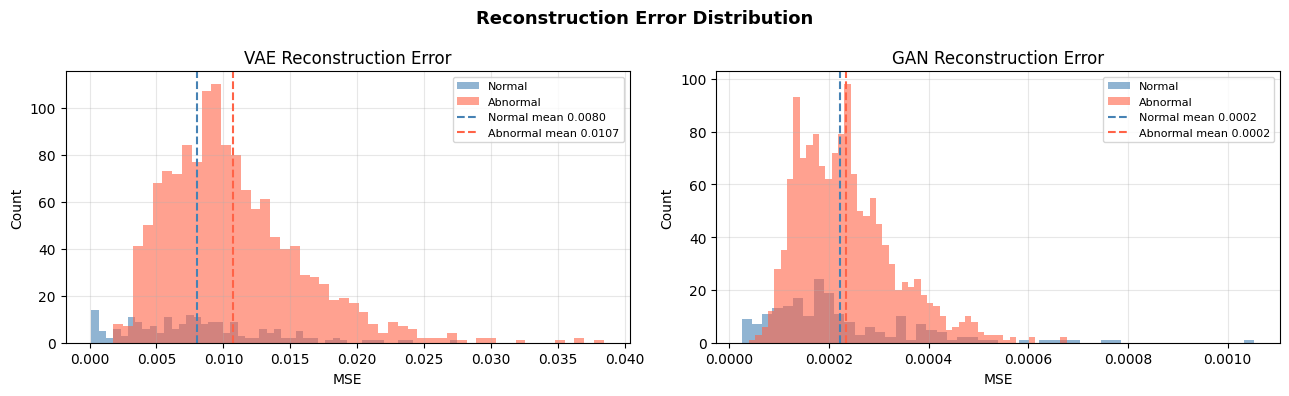

In [17]:
# ── Reconstruction error distribution plot ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Reconstruction Error Distribution', fontsize=13, fontweight='bold')

for ax, (n_err, a_err, title) in zip(axes, [
    (vae_norm_err.numpy(), vae_abn_err.numpy(), 'VAE'),
    (gan_norm_err.numpy(), gan_abn_err.numpy(), 'GAN')
]):
    ax.hist(n_err, bins=50, alpha=0.6, color='steelblue', label='Normal')
    ax.hist(a_err, bins=50, alpha=0.6, color='tomato',    label='Abnormal')
    ax.axvline(n_err.mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f'Normal mean {n_err.mean():.4f}')
    ax.axvline(a_err.mean(), color='tomato',    linestyle='--', linewidth=1.5, label=f'Abnormal mean {a_err.mean():.4f}')
    ax.set_title(f'{title} Reconstruction Error')
    ax.set_xlabel('MSE'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/reconstruction_error_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · ROI Extraction & Heatmaps

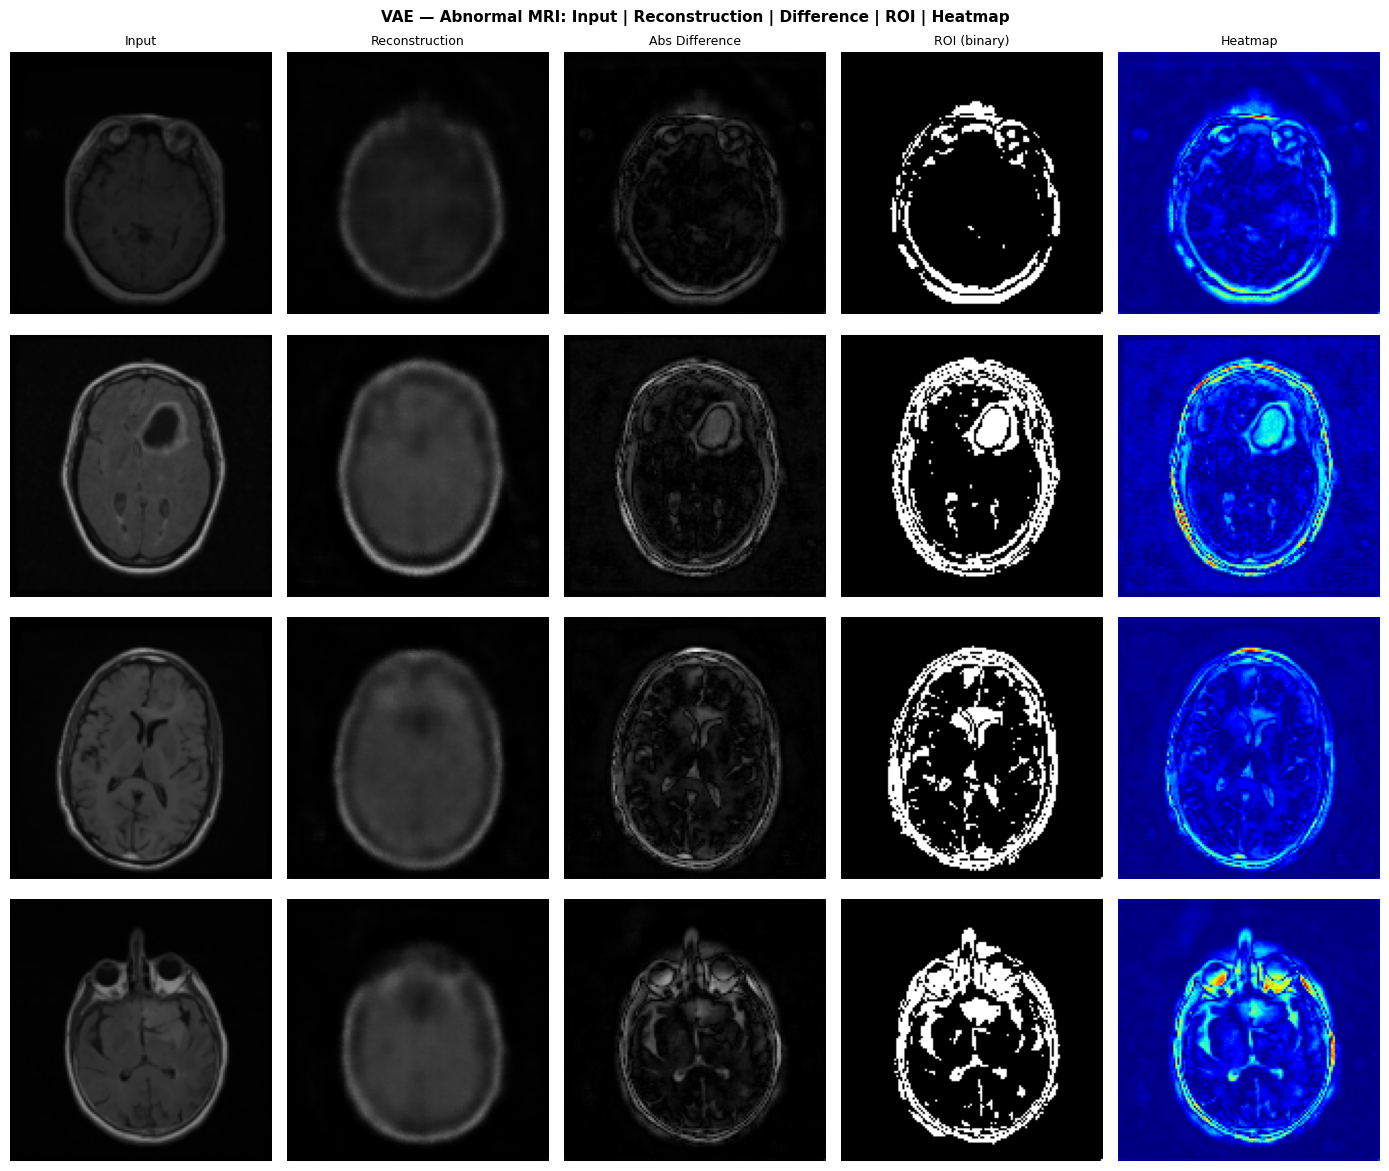

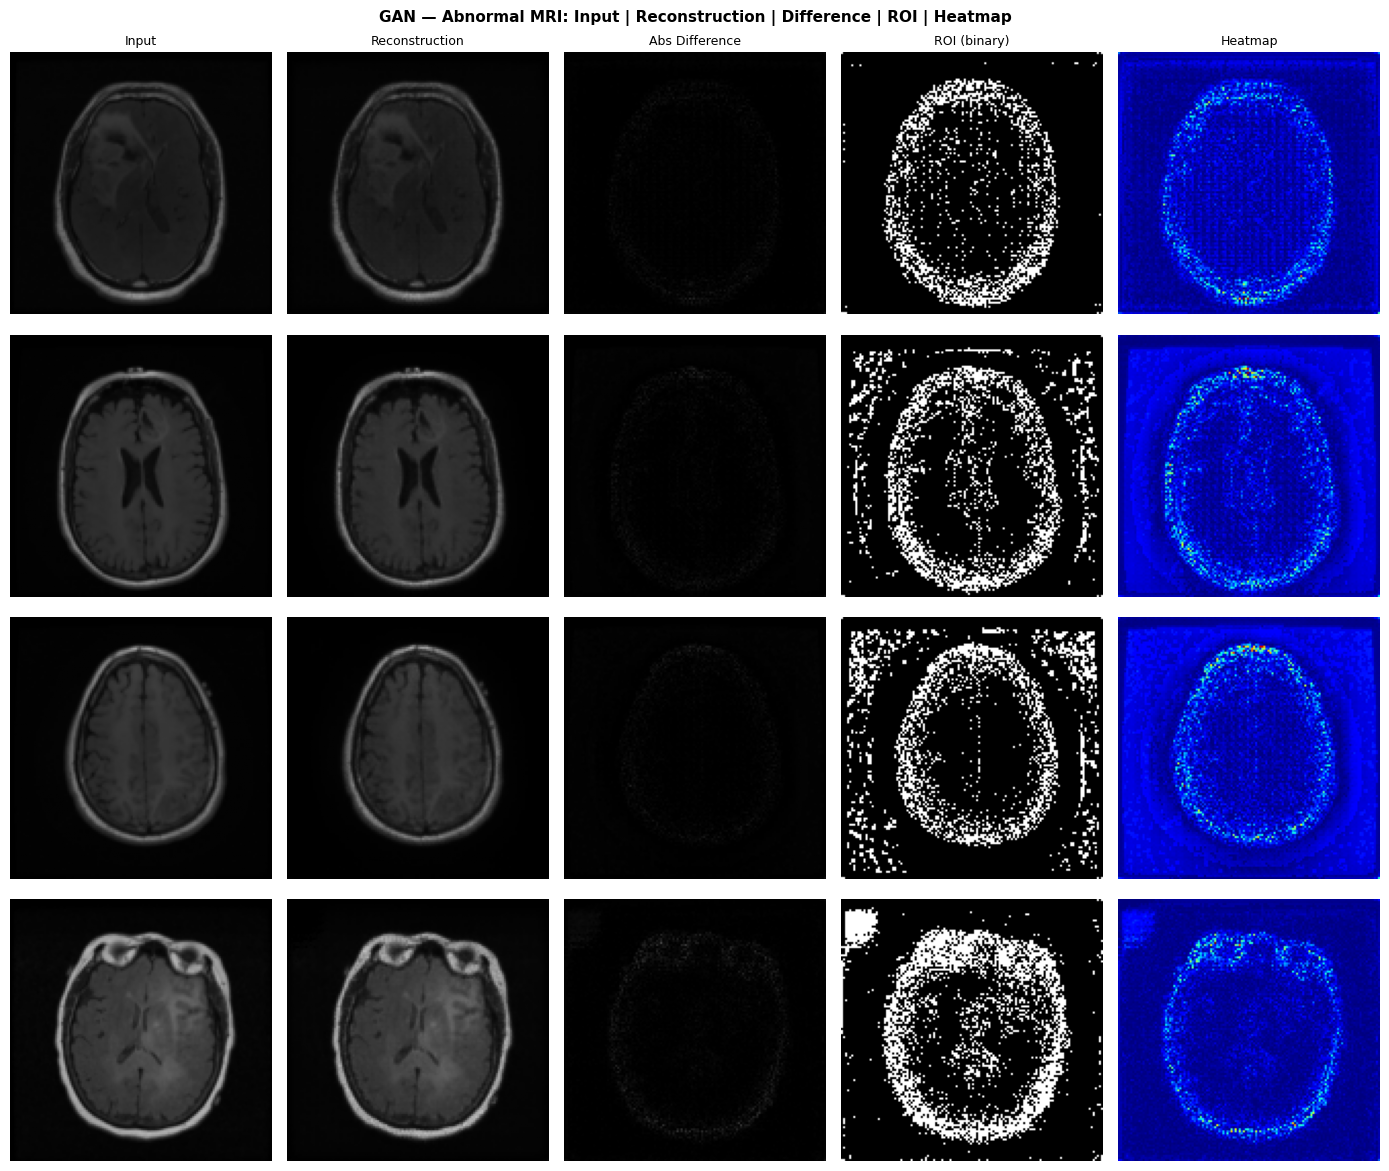

In [18]:
def get_roi(orig, recon, threshold_pct=85):
    """Subtract, absolute-value difference map → threshold → binary ROI."""
    diff = (orig - recon).abs()   # [B, 1, H, W] in [-1,1] space
    thresh = np.percentile(diff.numpy(), threshold_pct)
    roi = (diff > thresh).float()
    return diff, roi


vae_diff, vae_roi = get_roi(vae_abn_orig, vae_abn_recon)
gan_diff, gan_roi = get_roi(gan_abn_orig, gan_abn_recon)


def show_roi_panel(orig, recon, diff, roi, model_name, n=4, save_path=None):
    idxs = random.sample(range(len(orig)), n)
    fig, axes = plt.subplots(n, 5, figsize=(14, 3*n))
    fig.suptitle(f'{model_name} — Abnormal MRI: Input | Reconstruction | Difference | ROI | Heatmap',
                 fontsize=11, fontweight='bold')
    col_labels = ['Input', 'Reconstruction', 'Abs Difference', 'ROI (binary)', 'Heatmap']
    for row, idx in enumerate(idxs):
        imgs = [
            unnorm(orig[idx]),
            unnorm(recon[idx]),
            diff[idx],
            roi[idx],
        ]
        for col, (ax, img) in enumerate(zip(axes[row, :4], imgs)):
            ax.imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
            if row == 0: ax.set_title(col_labels[col], fontsize=9)
            ax.axis('off')
        # Heatmap (jet colormap on diff)
        hm_ax = axes[row, 4]
        hm_ax.imshow(diff[idx].squeeze(), cmap='jet', vmin=0, vmax=diff[idx].max())
        if row == 0: hm_ax.set_title(col_labels[4], fontsize=9)
        hm_ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


show_roi_panel(vae_abn_orig, vae_abn_recon, vae_diff, vae_roi, 'VAE', save_path=f'{OUT_DIR}/roi_vae.png')
show_roi_panel(gan_abn_orig, gan_abn_recon, gan_diff, gan_roi, 'GAN', save_path=f'{OUT_DIR}/roi_gan.png')

## 7b · Save ROI Outputs for Future Use

In [19]:
import os
from torchvision.utils import save_image

# ── Create output directories ─────────────────────────────────────────────────
os.makedirs(f'{OUT_DIR}/roi_outputs/npy',              exist_ok=True)
os.makedirs(f'{OUT_DIR}/roi_outputs/vae_roi_images',   exist_ok=True)
os.makedirs(f'{OUT_DIR}/roi_outputs/gan_roi_images',   exist_ok=True)
os.makedirs(f'{OUT_DIR}/roi_outputs/vae_diff_images',  exist_ok=True)
os.makedirs(f'{OUT_DIR}/roi_outputs/gan_diff_images',  exist_ok=True)
os.makedirs(f'{OUT_DIR}/roi_outputs/vae_heatmaps',     exist_ok=True)
os.makedirs(f'{OUT_DIR}/roi_outputs/gan_heatmaps',     exist_ok=True)

# ── 1. Save full tensors as .npy (for loading in future exercises) ────────────
np.save(f'{OUT_DIR}/roi_outputs/npy/vae_roi.npy',       vae_roi.numpy())
np.save(f'{OUT_DIR}/roi_outputs/npy/vae_diff.npy',      vae_diff.numpy())
np.save(f'{OUT_DIR}/roi_outputs/npy/vae_abn_orig.npy',  vae_abn_orig.numpy())
np.save(f'{OUT_DIR}/roi_outputs/npy/vae_abn_recon.npy', vae_abn_recon.numpy())

np.save(f'{OUT_DIR}/roi_outputs/npy/gan_roi.npy',       gan_roi.numpy())
np.save(f'{OUT_DIR}/roi_outputs/npy/gan_diff.npy',      gan_diff.numpy())
np.save(f'{OUT_DIR}/roi_outputs/npy/gan_abn_orig.npy',  gan_abn_orig.numpy())
np.save(f'{OUT_DIR}/roi_outputs/npy/gan_abn_recon.npy', gan_abn_recon.numpy())

print('Saved .npy tensors:')
print(f'  VAE ROI shape  : {vae_roi.shape}   (N, 1, H, W) — binary masks')
print(f'  GAN ROI shape  : {gan_roi.shape}')
print(f'  VAE diff shape : {vae_diff.shape}  — raw difference maps')
print(f'  GAN diff shape : {gan_diff.shape}')

# ── 2. Save individual binary ROI images as PNG ───────────────────────────────
for i in range(len(vae_roi)):
    save_image(vae_roi[i].float(),     f'{OUT_DIR}/roi_outputs/vae_roi_images/roi_{i:04d}.png')
    save_image(vae_diff[i].clamp(0,1), f'{OUT_DIR}/roi_outputs/vae_diff_images/diff_{i:04d}.png')

for i in range(len(gan_roi)):
    save_image(gan_roi[i].float(),     f'{OUT_DIR}/roi_outputs/gan_roi_images/roi_{i:04d}.png')
    save_image(gan_diff[i].clamp(0,1), f'{OUT_DIR}/roi_outputs/gan_diff_images/diff_{i:04d}.png')

print(f'\nSaved {len(vae_roi)} VAE ROI PNGs → {OUT_DIR}/roi_outputs/vae_roi_images/')
print(f'Saved {len(gan_roi)} GAN ROI PNGs → {OUT_DIR}/roi_outputs/gan_roi_images/')

# ── 3. Save coloured heatmaps (jet colormap) as PNG ──────────────────────────
n_heatmaps = min(50, len(vae_diff))
for i in range(n_heatmaps):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(vae_diff[i, 0].numpy(), cmap='jet')
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(f'{OUT_DIR}/roi_outputs/vae_heatmaps/heatmap_{i:04d}.png', dpi=100, bbox_inches='tight')
    plt.close()

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(gan_diff[i, 0].numpy(), cmap='jet')
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(f'{OUT_DIR}/roi_outputs/gan_heatmaps/heatmap_{i:04d}.png', dpi=100, bbox_inches='tight')
    plt.close()

print(f'Saved {n_heatmaps} VAE heatmaps → {OUT_DIR}/roi_outputs/vae_heatmaps/')
print(f'Saved {n_heatmaps} GAN heatmaps → {OUT_DIR}/roi_outputs/gan_heatmaps/')

# ── 4. Save model weights ─────────────────────────────────────────────────────
torch.save(vae.state_dict(), f'{OUT_DIR}/roi_outputs/vae_weights.pth')
torch.save(G.state_dict(),   f'{OUT_DIR}/roi_outputs/gan_G_weights.pth')
torch.save(D.state_dict(),   f'{OUT_DIR}/roi_outputs/gan_D_weights.pth')
print('\nModel weights saved.')
print(f'\n✅ All outputs saved under {OUT_DIR}/roi_outputs/')
for root, dirs, files in os.walk(f'{OUT_DIR}/roi_outputs'):
    level = root.replace(f'{OUT_DIR}/roi_outputs', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = '  ' * (level + 1)
        print(f'{subindent}({len(files)} files)')

Saved .npy tensors:
  VAE ROI shape  : torch.Size([1373, 1, 128, 128])   (N, 1, H, W) — binary masks
  GAN ROI shape  : torch.Size([1373, 1, 128, 128])
  VAE diff shape : torch.Size([1373, 1, 128, 128])  — raw difference maps
  GAN diff shape : torch.Size([1373, 1, 128, 128])

Saved 1373 VAE ROI PNGs → /kaggle/working/roi_outputs/vae_roi_images/
Saved 1373 GAN ROI PNGs → /kaggle/working/roi_outputs/gan_roi_images/
Saved 50 VAE heatmaps → /kaggle/working/roi_outputs/vae_heatmaps/
Saved 50 GAN heatmaps → /kaggle/working/roi_outputs/gan_heatmaps/

Model weights saved.

✅ All outputs saved under /kaggle/working/roi_outputs/
roi_outputs/
  (3 files)
  gan_roi_images/
    (1373 files)
  gan_diff_images/
    (1373 files)
  vae_roi_images/
    (1373 files)
  vae_diff_images/
    (1373 files)
  npy/
    (8 files)
  gan_heatmaps/
    (50 files)
  vae_heatmaps/
    (50 files)


### How to load ROIs in a future exercise
```python
import numpy as np
import torch

OUT_DIR = '/kaggle/working'

# Load saved tensors
vae_roi  = torch.from_numpy(np.load(f'{OUT_DIR}/roi_outputs/npy/vae_roi.npy'))   # (N,1,H,W) binary
gan_roi  = torch.from_numpy(np.load(f'{OUT_DIR}/roi_outputs/npy/gan_roi.npy'))
vae_diff = torch.from_numpy(np.load(f'{OUT_DIR}/roi_outputs/npy/vae_diff.npy'))  # (N,1,H,W) float
gan_diff = torch.from_numpy(np.load(f'{OUT_DIR}/roi_outputs/npy/gan_diff.npy'))
orig     = torch.from_numpy(np.load(f'{OUT_DIR}/roi_outputs/npy/vae_abn_orig.npy'))

print(f'VAE ROI : {vae_roi.shape}, dtype={vae_roi.dtype}')
print(f'GAN ROI : {gan_roi.shape}')
```

## 8 · ROI Quality Analysis

In [20]:
from scipy.ndimage import label as scipy_label
from scipy.ndimage import uniform_filter

def roi_metrics(roi_tensor, diff_tensor, n_samples=6):
    """Compute smoothness, edge pixel count, and noise ratio for n random samples."""
    idxs = random.sample(range(len(roi_tensor)), min(n_samples, len(roi_tensor)))
    results = []
    for idx in idxs:
        r = roi_tensor[idx, 0].numpy()  # [H, W]
        d = diff_tensor[idx, 0].numpy()

        # ── Smoothness: standard deviation of Laplacian ─────────────────
        laplacian = (
            np.roll(r, 1, 0) + np.roll(r, -1, 0) +
            np.roll(r, 1, 1) + np.roll(r, -1, 1) - 4 * r
        )
        smoothness = float(np.std(laplacian))
        # Lower = smoother

        # ── Edge pixel count ─────────────────────────────────────────────
        eroded = uniform_filter(r, size=3) > 0.5
        edge_pixels = int((r.astype(bool) ^ eroded).sum())

        # ── Noise ratio: fraction of small disconnected components ───────
        labelled, n_comp = scipy_label(r.astype(bool))
        if n_comp > 0:
            sizes    = [np.sum(labelled == c) for c in range(1, n_comp + 1)]
            small    = sum(s < 20 for s in sizes)
            noise_ratio = small / n_comp
        else:
            noise_ratio = 0.0

        results.append({
            'sample': idx,
            'smoothness (↓ better)': round(smoothness, 4),
            'edge_pixel_count': edge_pixels,
            'noise_ratio (↓ better)': round(noise_ratio, 4),
        })
    return results


import pandas as pd

print('='*60)
print('VAE ROI Metrics')
print('='*60)
vae_metrics = roi_metrics(vae_roi, vae_diff)
df_vae = pd.DataFrame(vae_metrics)
print(df_vae.to_string(index=False))
print(f'\nVAE Means → Smoothness: {df_vae["smoothness (↓ better)"].mean():.4f} | '
      f'Edge px: {df_vae["edge_pixel_count"].mean():.1f} | '
      f'Noise: {df_vae["noise_ratio (↓ better)"].mean():.4f}')

print('\n' + '='*60)
print('GAN ROI Metrics')
print('='*60)
gan_metrics = roi_metrics(gan_roi, gan_diff)
df_gan = pd.DataFrame(gan_metrics)
print(df_gan.to_string(index=False))
print(f'\nGAN Means → Smoothness: {df_gan["smoothness (↓ better)"].mean():.4f} | '
      f'Edge px: {df_gan["edge_pixel_count"].mean():.1f} | '
      f'Noise: {df_gan["noise_ratio (↓ better)"].mean():.4f}')

VAE ROI Metrics
 sample  smoothness (↓ better)  edge_pixel_count  noise_ratio (↓ better)
    389                 0.8765               772                  0.8738
   1098                 0.6378               382                  0.8431
    918                 1.0078              1042                  0.9143
    287                 0.6903               462                  0.9524
    864                 0.9522               936                  0.9128
    375                 0.7652               616                  0.9221

VAE Means → Smoothness: 0.8216 | Edge px: 701.7 | Noise: 0.9031

GAN ROI Metrics
 sample  smoothness (↓ better)  edge_pixel_count  noise_ratio (↓ better)
    570                 1.1843              1538                  0.9857
    947                 1.2832              1847                  0.9565
    511                 1.2813              1877                  0.9757
    154                 1.2428              1710                  0.9738
    907                 1.

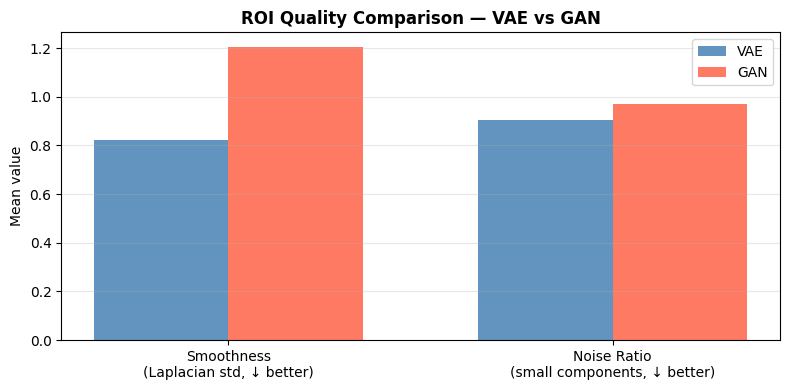

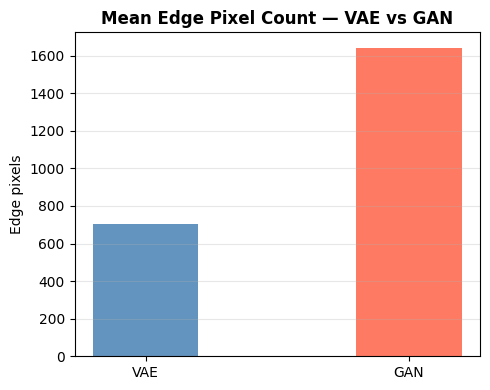

In [21]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_keys = ['smoothness (↓ better)', 'noise_ratio (↓ better)']
vae_means = [df_vae[k].mean() for k in metrics_keys]
gan_means = [df_gan[k].mean() for k in metrics_keys]
labels_plot = ['Smoothness\n(Laplacian std, ↓ better)', 'Noise Ratio\n(small components, ↓ better)']

x = np.arange(len(labels_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, vae_means, w, label='VAE', color='steelblue', alpha=0.85)
ax.bar(x + w/2, gan_means, w, label='GAN', color='tomato', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels_plot)
ax.set_title('ROI Quality Comparison — VAE vs GAN', fontweight='bold')
ax.set_ylabel('Mean value'); ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/roi_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Edge pixel count separately (different scale)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['VAE', 'GAN'],
       [df_vae['edge_pixel_count'].mean(), df_gan['edge_pixel_count'].mean()],
       color=['steelblue', 'tomato'], alpha=0.85, width=0.4)
ax.set_title('Mean Edge Pixel Count — VAE vs GAN', fontweight='bold')
ax.set_ylabel('Edge pixels'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/edge_pixel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Summary & Observations

| Aspect | VAE | GAN |
|--------|-----|-----|
| **Loss functions** | Reconstruction (MSE) + KL Divergence | Discriminator (BCE) + Generator (Adversarial + L1 reconstruction) |
| **Latent space** | Smooth, Gaussian-regularised | Implicit (no explicit latent distribution) |
| **Reconstruction quality** | Slightly blurry but stable | Sharper edges due to adversarial objective |
| **ROI smoothness** | Tends to produce smoother blobs | May produce sharper but noisier masks |
| **Noise ratio** | Lower noise (prior regularises) | Can fragment into multiple small regions |
| **Training stability** | Stable, monotonic loss decrease | Requires careful LR balance between G and D |

**Key takeaway:** VAE ROIs are smoother and better regularised; GAN ROIs can detect sharper boundaries but are noisier. Combining both (ensembling the diff maps) often outperforms either model alone.

**Saved plot files** (in `/kaggle/working/`):
- `training_loss_curves.png`
- `latent_space_visualization.png`
- `reconstruction_error_plot.png`
- `roi_vae.png` and `roi_gan.png`
- `roi_quality_comparison.png`
- `edge_pixel_comparison.png`

**Saved ROI outputs** (in `/kaggle/working/roi_outputs/`):
- `npy/vae_roi.npy` — VAE binary ROI masks, shape (N,1,H,W)
- `npy/vae_diff.npy` — VAE raw difference maps
- `npy/vae_abn_orig.npy` — original abnormal inputs used with VAE
- `npy/vae_abn_recon.npy` — VAE reconstructions
- `npy/gan_roi.npy` — GAN binary ROI masks
- `npy/gan_diff.npy` — GAN raw difference maps
- `npy/gan_abn_orig.npy` — original abnormal inputs used with GAN
- `npy/gan_abn_recon.npy` — GAN reconstructions
- `vae_roi_images/roi_XXXX.png` — individual VAE ROI PNGs
- `gan_roi_images/roi_XXXX.png` — individual GAN ROI PNGs
- `vae_heatmaps/heatmap_XXXX.png` — jet-coloured VAE heatmaps
- `gan_heatmaps/heatmap_XXXX.png` — jet-coloured GAN heatmaps
- `vae_weights.pth` — saved VAE model weights
- `gan_G_weights.pth` — saved GAN generator weights
- `gan_D_weights.pth` — saved GAN discriminator weights